 # RAG Chatbot & GraphRAG Pipeline Interactive Tester 🚀

 Use VS Code's interactive window (click "Run Cell" above each block) to test and debug

 each component of Umer's portfolio chatbot dynamically.

 ### Cell 1: Environment & Settings Initialization

 Loads environment variables, configures settings, and initializes logging.

In [1]:
import os
import sys
from pathlib import Path

# Resolve project root dynamically (searches upward for 'app' directory)
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir
for parent in [current_dir] + list(current_dir.parents):
    if (parent / "app").exists():
        project_root = parent
        break

sys.path.append(str(project_root))

In [2]:
from app.core import get_settings, setup_logging, get_logger, get_embeddings_model
setup_logging()
logger = get_logger("interactive_tester")
settings = get_settings()

print("✅ Settings & Env loaded.")
print(f"Project root added to path: {project_root}")
print(f"Active collection: {settings.qdrant.collection_name}")
print(f"Active LLM: {settings.app.model_name}")

Logfire project URL: https://logfire-us.pydantic.dev/muhammadumerk546/starter-project

✅ Settings & Env loaded.
Project root added to path: C:\portfolio-web-bot
Active collection: personal_kb
Active LLM: openai/gpt-oss-120b


 ### Cell 2: Test Qdrant Scroll Loader (Phase 4b)

 Fetches all points from Qdrant Cloud. This simulates what happens at server startup.

In [3]:
from app.services.retrieval.qdrant_service import QdrantRetrievalService

print("Connecting to Qdrant Cloud and scrolling collection...")
qdrant_service = QdrantRetrievalService()
chunks_data = qdrant_service.fetch_all_chunks()

print(f"\n✅ Scroll complete. Fetched {len(chunks_data)} total chunks from Qdrant Cloud.")
if chunks_data:
    print("\nSample Chunk Payload:")
    import pprint
    pprint.pprint(chunks_data[0])

Connecting to Qdrant Cloud and scrolling collection...
22:10:02.802 Initializing local HuggingFace embeddings model: BAAI/bge-base-en-v1.5


22:10:05.516 HTTP Request: GET https://e79d6ad7-2732-4220-bafd-b2a247d7f9ea.us-west-1-0.aws.cloud.qdrant.io:6333 "HTTP/1.1 200 OK"
22:10:05.681 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
22:10:05.682 Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
22:10:05.702 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/modules.json "HTTP/1.1 200 OK"
22:10:05.945 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
22:10:05.978 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config_sentence_transformers.json "HTTP/1.1 200 OK"
22:10:05.980 Loading SentenceTransformer model from BA

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

22:10:08.049 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
22:10:08.310 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:08.564 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:08.806 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:09.051 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
22:10:09.088 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/tokenizer_config.json "HTTP/1.1 200 OK"
22:10:09.317 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config.json "HTTP/

 ### Cell 3: Test Dynamic BM25 In-Memory Indexing

 Tests how the BM25 index is compiled from the fetched Qdrant payloads in RAM.

In [4]:
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever

print("Compiling BM25 index in RAM...")
documents = []
for item in chunks_data:
    meta = item.get("metadata", {})
    meta.setdefault("source_type", item.get("source_type"))
    meta.setdefault("source_path", item.get("source_path"))
    meta.setdefault("project_name", item.get("project_name"))
    
    doc = Document(
        page_content=item.get("content", ""),
        metadata=meta
    )
    documents.append(doc)

bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 3

# Test query
query = "DineMate"
results = bm25_retriever.invoke(query)

print(f"✅ BM25 indexed {len(documents)} documents successfully.")
print(f"\nBM25 Search Results for '{query}':")
for idx, r in enumerate(results):
    print(f"\nMatch {idx+1} [Source: {r.metadata.get('source_path')}]:")
    print(r.page_content[:200] + "...")


Compiling BM25 index in RAM...
✅ BM25 indexed 898 documents successfully.

BM25 Search Results for 'DineMate':

Match 1 [Source: C:\portfolio-web-bot\data\raw\github\DineMate-Agentic-AI-for-Automated-Food-Ordering\scripts\README.md]:
## © 2025 DineMate AI
Built with ❤️ by Muhammad Umer Khan. Powering a smarter dining experience! 🍕...

Match 2 [Source: C:\portfolio-web-bot\data\raw\github\DineMate-Agentic-AI-for-Automated-Food-Ordering\app\README.md]:
## © 2025 DineMate AI
Built with ❤️ by Muhammad Umer Khan. Powered by AI for a smarter dining experience! 🍔...

Match 3 [Source: C:\portfolio-web-bot\data\raw\github\DineMate-Agentic-AI-for-Automated-Food-Ordering\README.md]:
## 🤝 **Contributions**
Contributions are welcome! Fork, submit pull requests, or suggest improvements.  
---  
**© 2025 DineMate AI | Built with ❤️ by Muhammad Umer Khan** 🚀🍔...


 ### Cell 4: Test In-Memory Knowledge Graph Compilation & Search (Phase 4a)

 Tests graph builder compiling the adjacency list in RAM and GraphService resolving queries.

In [5]:
from app.ingestion.graph_builder import build_graph
from app.services.graph_service import GraphService

print("Compiling lightweight Knowledge Graph adjacency list...")
graph_dict = build_graph(chunks_data)
graph_service = GraphService(graph_dict=graph_dict)

# Test query
graph_query = "FastAPI"
graph_context = graph_service.query_graph(graph_query)

print(f"\n✅ Knowledge graph built with {len(graph_dict)} unique nodes.")
print(f"\nGraph Search Context lookup for '{graph_query}':")
print(graph_context if graph_context else "No entity matched in graph.")


Compiling lightweight Knowledge Graph adjacency list...
22:10:13.136 ✅ Knowledge graph initialized from in-memory dictionary with 85 nodes.
22:10:13.142 🎯 Knowledge Graph hit: matched 1 entities.

✅ Knowledge graph built with 85 unique nodes.

Graph Search Context lookup for 'FastAPI':


[Lightweight Knowledge Graph Context]
- 'FastAPI' (Skill) is associated with: used in 'ChurnSage-MLOps-Driven-Customer-Retention', 'Internship-Projects', 'MuhammadUmerKhan', 'SupportGenie-Dual-Fine-Tuned-LLM-Customer-Support-Chatbot'


 ### Cell 5: Test FlashRank Reranker (Phase 3)

 Tests combining Dense + Sparse outputs and reranking them on CPU.

In [6]:
from app.services.retrieval.ranking_service import RankingService

print("Initializing local FlashRank CPU cross-encoder...")
ranking_service = RankingService()

# 1. Fetch dense matches from Qdrant
dense_docs = qdrant_service.retrieve("FastAPI projects", limit=5)
# 2. Fetch sparse matches from BM25
sparse_docs = bm25_retriever.invoke("FastAPI projects")

# 3. Combine
combined = dense_docs + sparse_docs

# 4. Rerank
reranked = ranking_service.rerank("FastAPI projects", combined, top_n=2)

print("\n✅ FlashRank Rerank complete.")
print("\nTop 2 Reranked Matches:")
for idx, r in enumerate(reranked):
    # Safely fetch 'rerank_score' with a fallback of 0.0
    score = r.metadata.get('rerank_score') or 0.0
    print(f"\nRank {idx+1} (Score: {score:.4f}):")
    print(r.page_content[:200] + "...")

Initializing local FlashRank CPU cross-encoder...
22:10:13.221 Initializing local FlashRank ranker...
22:10:13.510 ✅ FlashRank initialized successfully (model: ms-marco-MiniLM-L-12-v2)
22:10:14.166 HTTP Request: POST https://e79d6ad7-2732-4220-bafd-b2a247d7f9ea.us-west-1-0.aws.cloud.qdrant.io:6333/collections/personal_kb/points/query "HTTP/1.1 200 OK"
22:10:14.473 🎯 Reranked 8 candidates to top 2 results.

✅ FlashRank Rerank complete.

Top 2 Reranked Matches:

Rank 1 (Score: 0.9719):
## **📌 Conclusion**
This project demonstrates a **complete MLOps workflow** integrating:<br>
✅ **MLflow for experiment tracking**
✅ **FastAPI for real-time model deployment**
✅ **ChatQrok LLM for feed...

Rank 2 (Score: 0.9049):
## 🔥 **Project Features**
🔹 **End-to-End Automated MLOps Pipeline**
🔹 **MLflow for Experiment Tracking & Model Registry**
🔹 **Automated Model Training, Selection & Evaluation**
🔹 **Artifact Storage & ...


 ### Cell 6: Test Stateful LangGraph Agent E2E (Phase 5)

 Starts the compiled chatbot service and executes a conversation thread to verify state.

In [7]:
from app.services.chatbot import CustomDocChatbot

print("Eagerly booting CustomDocChatbot (loads Qdrant, builds BM25 & Graph)...")
chatbot = CustomDocChatbot()


c:\portfolio-web-bot\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Eagerly booting CustomDocChatbot (loads Qdrant, builds BM25 & Graph)...
22:10:17.355 {'message': '✅ Groq LLM configured successfully'}
22:10:17.357 Initializing local HuggingFace embeddings model: BAAI/bge-base-en-v1.5
22:10:17.780 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
22:10:17.808 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/modules.json "HTTP/1.1 200 OK"
22:10:18.052 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
22:10:18.078 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config_sentence_transformers.json "HTTP/1.1 200 OK"
22:10:18.082 Loading SentenceTransformer model from BAAI/bge-base-en-v1.5.
22:10:18.320 HTTP Request: HEAD https://hu

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

22:10:20.471 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
22:10:20.717 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:20.967 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:21.232 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:21.487 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
22:10:21.511 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/tokenizer_config.json "HTTP/1.1 200 OK"
22:10:21.766 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config.json "HTTP/

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

22:10:27.248 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
22:10:27.501 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:27.746 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:27.989 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:10:28.231 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
22:10:28.251 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/tokenizer_config.json "HTTP/1.1 200 OK"
22:10:28.491 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config.json "HTTP/

In [9]:
# # Ask greeting (routes to direct chat)
# q1 = "Hello, what is your name?"
# print(f"Query: {q1}")
# ans1 = chatbot.setup_and_query(q1, thread_id="test_session")
# print(f"Answer: {ans1}\n")

# # Ask semantic project query (routes to tools retrieval)
# q2 = "What did Umer build for Society Management?"
# print(f"Query: {q2}")
# ans2 = chatbot.setup_and_query(q2, thread_id="test_session")
# print(f"Answer: {ans2}\n")

# # Follow up to test conversation memory
# q3 = "What technologies were used in that project?"
# print(f"Query: {q3}")
# ans3 = chatbot.setup_and_query(q3, thread_id="test_session")
# print(f"Answer: {ans3}\n")


In [17]:
from IPython.display import Image, display
from app.agents.graph import create_agent_graph
from app.services.chatbot import CustomDocChatbot

In [13]:
# 1. Initialize the chatbot (needed to supply retrieval contexts and tools)
chatbot = CustomDocChatbot()
# 2. Construct the compiled LangGraph workflow
agent_graph = create_agent_graph(chatbot)

22:16:51.519 {'message': '✅ Groq LLM configured successfully'}
22:16:51.519 Initializing local HuggingFace embeddings model: BAAI/bge-base-en-v1.5
22:16:51.819 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
22:16:51.850 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/modules.json "HTTP/1.1 200 OK"
22:16:52.092 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
22:16:52.118 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config_sentence_transformers.json "HTTP/1.1 200 OK"
22:16:52.123 Loading SentenceTransformer model from BAAI/bge-base-en-v1.5.
22:16:52.359 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transfor

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

22:16:54.081 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
22:16:54.348 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:16:54.601 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
22:16:54.855 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:16:55.108 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
22:16:55.137 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/tokenizer_config.json "HTTP/1.1 200 OK"
22:16:55.380 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config.json "HTTP/

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

22:17:01.099 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
22:17:01.364 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:17:01.619 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"


Currently retrying 1 failed export(s) (1445 bytes)
Failed to export span batch code: None, reason: HTTPSConnectionPool(host='logfire-us.pydantic.dev', port=443): Read timed out. (read timeout=10.0)


22:17:01.872 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
22:17:02.143 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
22:17:02.195 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/tokenizer_config.json "HTTP/1.1 200 OK"
22:17:02.438 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:17:02.467 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config.json "HTTP/1.1 200 OK"
22:17:02.715 HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:17:02.751 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/b

22:17:26.862 GET mermaid.ink/img/LS0tCmNvbmZpZzoKICBmbG93Y2hhcnQ6CiAgICBjdXJ2ZTogbGluZWFyCi0tLQpncmFwaCBURDsKCV9fc3RhcnRfXyhbPHA+X19zdGFydF9fPC9wPl0pOjo6Zmlyc3QKCXBsYW5uZXIocGxhbm5lcikKCXJldHJpZXZlcihyZXRyaWV2ZXIpCglyZXNwb25kZXIocmVzcG9uZGVyKQoJX19lbmRfXyhbPHA+X19lbmRfXzwvcD5dKTo6Omxhc3QKCV9fc3RhcnRfXyAtLT4gcGxhbm5lcjsKCXBsYW5uZXIgLS4tPiBfX2VuZF9fOwoJcGxhbm5lciAtLi0+IHJldHJpZXZlcjsKCXJldHJpZXZlciAtLT4gcmVzcG9uZGVyOwoJcmVzcG9uZGVyIC0tPiBfX2VuZF9fOwoJY2xhc3NEZWYgZGVmYXVsdCBmaWxsOiNmMmYwZmYsbGluZS1oZWlnaHQ6MS4yCgljbGFzc0RlZiBmaXJzdCBmaWxsLW9wYWNpdHk6MAoJY2xhc3NEZWYgbGFzdCBmaWxsOiNiZmI2ZmMK ? type='png' & bgColor='!white'


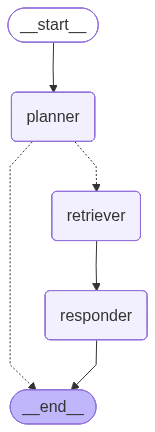

In [14]:
# 3. Render and display the PNG diagram
try:
    display(Image(agent_graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    print(f"Could not render PNG directly: {e}")
    print("\nAlternative (Mermaid markdown markup):")
    print("Copy the text below and paste it into https://mermaid.live to visualize it:")
    print(agent_graph.get_graph(xray=1).draw_mermaid())

In [31]:
from app.agents.nodes.planner import get_planner_node
from app.agents.nodes.retriever import get_retriever_node
from app.agents.nodes.responder import  get_responder_node

from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

In [34]:
planner_node = get_planner_node(chatbot)
retriever_node, tools = get_retriever_node(chatbot)
responder_node = get_responder_node(chatbot)

In [35]:
vector_search, graph_search = tools

In [44]:
response = await vector_search.ainvoke("Tell me about DineMate")

22:37:00.264 HTTP Request: POST https://e79d6ad7-2732-4220-bafd-b2a247d7f9ea.us-west-1-0.aws.cloud.qdrant.io:6333/collections/personal_kb/points/query "HTTP/1.1 200 OK"
22:37:04.596 🎯 Reranked 17 candidates to top 4 results.


In [48]:
from IPython.core.display import Markdown
# display(Markdown(response))

In [51]:
response = await graph_search.ainvoke("Tell me about the projects you worked on the FastAPI")
response

22:39:13.665 🎯 Knowledge Graph hit: matched 1 entities.


"\n\n[Lightweight Knowledge Graph Context]\n- 'FastAPI' (Skill) is associated with: used in 'ChurnSage-MLOps-Driven-Customer-Retention', 'Internship-Projects', 'MuhammadUmerKhan', 'SupportGenie-Dual-Fine-Tuned-LLM-Customer-Support-Chatbot'"

In [52]:
display(Markdown(response))



[Lightweight Knowledge Graph Context]
- 'FastAPI' (Skill) is associated with: used in 'ChurnSage-MLOps-Driven-Customer-Retention', 'Internship-Projects', 'MuhammadUmerKhan', 'SupportGenie-Dual-Fine-Tuned-LLM-Customer-Support-Chatbot'

In [53]:
state = {
    "messages": [HumanMessage(content="What projects did Umer build with FastAPI?")],
    "retrieved_docs": [],
    "graph_context": ""
}
print("Initial State Input:")
print(state)    

Initial State Input:
{'messages': [HumanMessage(content='What projects did Umer build with FastAPI?', additional_kwargs={}, response_metadata={})], 'retrieved_docs': [], 'graph_context': ''}


In [55]:
planner_output = planner_node(state)

22:40:57.064 HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [58]:
planner_output["messages"][0]

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to decide which tool. The user asks: "What projects did Umer build with FastAPI?" That\'s a relational query: which projects (entities) built with a specific tech (FastAPI). That\'s a relationship query, so use graph_search. Possibly also need vector? According to guidelines, relational query => graph_search. So we should call graph_search with query.', 'tool_calls': [{'id': 'fc_bd1a60fa-5b01-425e-afc6-50fc22c5745b', 'function': {'arguments': '{"query":"projects built with FastAPI by Umer"}', 'name': 'graph_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 374, 'total_tokens': 484, 'completion_time': 0.23177608, 'prompt_time': 0.016048806, 'queue_time': 0.234659706, 'total_time': 0.247824886, 'completion_tokens_details': {'reasoning_tokens': 76}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_803c0ba83d', 'service_tier': 'on_demand', 'fini

In [59]:
state["messages"].append(planner_output["messages"][0])

In [ ]:
retriever_output = retriever_node(state)

22:45:46.798 🎯 Knowledge Graph hit: matched 1 entities.


Currently retrying 1 failed export(s) (825 bytes)
Failed to export span batch code: None, reason: HTTPSConnectionPool(host='logfire-us.pydantic.dev', port=443): Read timed out. (read timeout=10.0)


In [61]:
retriever_output

{'messages': [ToolMessage(content="\n\n[Lightweight Knowledge Graph Context]\n- 'FastAPI' (Skill) is associated with: used in 'ChurnSage-MLOps-Driven-Customer-Retention', 'Internship-Projects', 'MuhammadUmerKhan', 'SupportGenie-Dual-Fine-Tuned-LLM-Customer-Support-Chatbot'", name='graph_search', tool_call_id='fc_bd1a60fa-5b01-425e-afc6-50fc22c5745b')],
 'retrieved_docs': [],
 'graph_context': "\n\n[Lightweight Knowledge Graph Context]\n- 'FastAPI' (Skill) is associated with: used in 'ChurnSage-MLOps-Driven-Customer-Retention', 'Internship-Projects', 'MuhammadUmerKhan', 'SupportGenie-Dual-Fine-Tuned-LLM-Customer-Support-Chatbot'"}

In [62]:
state["messages"].extend(retriever_output["messages"])
state["retrieved_docs"] = retriever_output["retrieved_docs"]
state["graph_context"] = retriever_output["graph_context"]

In [63]:
responder_output = responder_node(state)
print("\n--- 3. Responder Output (Final Response) ---")
print(responder_output["messages"][0].content)

22:50:25.717 HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"

--- 3. Responder Output (Final Response) ---
- **ChurnSage – MLOps‑Driven Customer Retention** 🚀  
- **Internship Projects** 💼  
- **SupportGenie – Dual Fine‑Tuned LLM Customer Support Chatbot** 🤖  

These are the projects where Umer utilized FastAPI. 😊
